In [1]:
# import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


# Load in our libraries
import pandas as pd
import numpy as np
from numpy import interp
import re
import sklearn
import xgboost as xgb
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-white')
%matplotlib inline

import scipy.stats as st
matplotlib.rcParams.update({'font.size': 12})

import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
 
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Markdown, display
 
# Going to use these 5 base models for the stacking
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection  import KFold,train_test_split

from sklearn.metrics import roc_curve, auc, recall_score, f1_score, precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import average_precision_score, multilabel_confusion_matrix, confusion_matrix
from sklearn import metrics


from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

import shap

# IBM's fairness tooolbox:
from aif360.datasets import BinaryLabelDataset  # To handle the data
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric  # For calculating metrics
from aif360.explainers import MetricTextExplainer  # For explaining metrics
from aif360.algorithms.preprocessing import Reweighing  # Preprocessing technique

from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import LFR, Reweighing


Bad key "text.kerning_factor" on line 4 in
F:\software\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


pip install 'aif360[LawSchoolGPA]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'


# 加载 所有数据

In [2]:
data_file = "../data_preprocess.csv"
df = pd.read_csv(data_file)
df

,subject_id,hadm_id,stay_id,first_careunit,los_icu_day,los_hospital_day,death_hosp,death_30day,death_90day,death_1year,...,fio2_max_eva_flag,troponin_max_eva_flag,lymphocytes_max_eva_flag,lymphocytes_min_eva_flag,neutrophils_min_eva_flag,pt_max_leave_eva_flag,ptt_max_leave_eva_flag,inr_min_leave_eva_flag,weight_diff,spo2_fio2_ratio
0,3,145834,211552,MICU,6.06,10.78,0,0,0,1,...,1,0,1,1,1,1,1,1,11.2,7400.000000
1,9,150750,220597,MICU,5.32,4.88,1,0,0,0,...,1,0,1,1,1,0,0,0,-1.7,15833.333333
2,21,109451,217847,CCU,5.90,13.17,0,0,0,1,...,1,1,1,1,1,1,1,1,0.0,9500.000000
3,26,197661,244882,CCU,2.14,6.99,0,0,0,0,...,0,0,0,0,0,1,1,1,44.4,45714.285714
4,30,104557,225176,CCU,1.85,5.01,0,0,0,0,...,0,0,1,1,1,0,1,0,0.0,42380.952381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12851,19997293,20208898,31629173,SICU,5.21,18.06,0,0,0,0,...,1,0,0,0,0,1,1,1,-23.2,9100.000000
12852,19997448,23560173,33380030,CCU,2.25,8.10,0,0,0,0,...,1,0,1,1,1,1,1,1,2.1,9300.000000
12853,19997473,27787494,32568753,CCU,3.63,21.62,0,0,0,0,...,0,1,0,0,0,1,1,1,0.6,44761.904762
12854,19997752,29452285,34531437,CCU,5.00,10.71,0,0,0,0,...,1,1,1,1,1,1,1,1,-3.5,18600.000000


# 排除院内死亡病例

In [3]:
df_disch = df[df.death_hosp==0].reset_index(drop=True) 
df_disch

,subject_id,hadm_id,stay_id,first_careunit,los_icu_day,los_hospital_day,death_hosp,death_30day,death_90day,death_1year,...,fio2_max_eva_flag,troponin_max_eva_flag,lymphocytes_max_eva_flag,lymphocytes_min_eva_flag,neutrophils_min_eva_flag,pt_max_leave_eva_flag,ptt_max_leave_eva_flag,inr_min_leave_eva_flag,weight_diff,spo2_fio2_ratio
0,3,145834,211552,MICU,6.06,10.78,0,0,0,1,...,1,0,1,1,1,1,1,1,11.2,7400.000000
1,21,109451,217847,CCU,5.90,13.17,0,0,0,1,...,1,1,1,1,1,1,1,1,0.0,9500.000000
2,26,197661,244882,CCU,2.14,6.99,0,0,0,0,...,0,0,0,0,0,1,1,1,44.4,45714.285714
3,30,104557,225176,CCU,1.85,5.01,0,0,0,0,...,0,0,1,1,1,0,1,0,0.0,42380.952381
4,37,188670,213503,MICU,1.14,5.09,0,0,0,0,...,0,1,1,1,1,1,1,1,0.0,42380.952381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10985,19997293,20208898,31629173,SICU,5.21,18.06,0,0,0,0,...,1,0,0,0,0,1,1,1,-23.2,9100.000000
10986,19997448,23560173,33380030,CCU,2.25,8.10,0,0,0,0,...,1,0,1,1,1,1,1,1,2.1,9300.000000
10987,19997473,27787494,32568753,CCU,3.63,21.62,0,0,0,0,...,0,1,0,0,0,1,1,1,0.6,44761.904762
10988,19997752,29452285,34531437,CCU,5.00,10.71,0,0,0,0,...,1,1,1,1,1,1,1,1,-3.5,18600.000000


In [4]:
df_disch['death_1year_new'] = df_disch['death_30day'] + df_disch['death_90day'] +df_disch['death_1year']
df_disch['death_1year_new'].value_counts()

0    9509
1    1481
Name: death_1year_new, dtype: int64

In [5]:
df.loc[df[df['insurance']==1].index, ['Medicaid']] = 1
df.loc[df[df['insurance']==0].index, ['Medicare']] = 1

print(df.Medicare.value_counts())
print(df.Medicaid.value_counts())

1    8483
0    4373
Name: Medicare, dtype: int64
0    12289
1      567
Name: Medicaid, dtype: int64


# 数据提取

In [8]:
# 选取列
select_columns = ["pre_icu_los_day","admission_type",'age','gender', 'ethnicity', 'marital_status',
                  'weight', 'weight_leave', 'weight_diff','spo2_fio2_ratio',
                  'bmi',
                  "insurance",
#                   'Medicaid', 'Medicare',
                  "language", 
#                   "language_english", "language_unknown", "language_other",
                  "electivesurgery", "vent", 
                  'creatinine_max','bilirubin_max',
                  'platelet_min','bun_max','wbc_max', 'glucose_max',
                  'hematocrit_max','potassium_max','sodium_max','bicarbonate_min','bicarbonate_max',# 'pao2fio2ratio_novent',
#                   'pao2fio2ratio_vent',
                  'albumin_min','alt_max','ast_max','alp_max', 'pt_max',
                  'ptt_max','inr_min', 'hemoglobin_min','chloride_min','pao2_min','paco2_max', 'lactate_max',
                  'baseexcess_min','fio2_max','troponin_max', 'lymphocytes_max','lymphocytes_min', 'neutrophils_min',
                  'magnesium_max',#'fibrinogen_min',#'bnp_max',
                  'aniongap_max','gcs_min', #'gcseyes', 'gcsmotor','gcsverbal',
                  'urineoutput','spo2_min','heart_rate_mean', 'mbp_mean',
                  'sbp_mean','resp_rate_mean','temperature_mean',
                  
                  'vasopressor', 'milrinone', 'furosemide', # 升压药、强心剂、利尿剂
                  
                  'bilirubin_max_eva_flag', 'albumin_min_eva_flag', 'alt_max_eva_flag', 
                  'ast_max_eva_flag', 'alp_max_eva_flag', 'pao2_min_eva_flag', 'paco2_max_eva_flag', 'lactate_max_eva_flag', 
                  'baseexcess_min_eva_flag', 'fio2_max_eva_flag', 'troponin_max_eva_flag', 'lymphocytes_max_eva_flag',
                  'lymphocytes_min_eva_flag', 'neutrophils_min_eva_flag', 
                  
                   'activity', #'activity_eva_flag', 
                   'fall_risk', #'fall_risk_eva_flag',# 'history_fall', 'history_fall_eva_flag',
                   'braden_nutrition', #'braden_nutrition_eva_flag', 
                   'braden_mobility', #'braden_mobility_eva_flag',
                   'braden_activity', #'braden_activity_eva_flag', #'edema_location', 'edema_location_eva_flag',

                   'lll_lung_sounds', #'lll_lung_sounds_eva_flag', 
                   'lul_lung_sounds', #'lul_lung_sounds_eva_flag',
                   'rll_lung_sounds', #'rll_lung_sounds_eva_flag', 
                   'rul_lung_sounds', #'rul_lung_sounds_eva_flag',
#                    'apsiii','saps','sofa',
                   'cci_score', #, 'anchor_year_group', 'db_source',
                  'death_1year_new',
                  
                  'vent_leave', 'creatinine_max_leave', #'bilirubin_max_leave',
                  'platelet_min_leave','bun_max_leave','wbc_max_leave','glucose_max_leave',
                  'hematocrit_max_leave','potassium_max_leave','sodium_max_leave','bicarbonate_min_leave','bicarbonate_max_leave',
                  #'pao2fio2ratio_novent_leave','pao2fio2ratio_vent_leave','albumin_min_leave', 'alt_max_leave', 'ast_max_leave', 'alp_max_leave',
                  'pt_max_leave', 'ptt_max_leave', 'inr_min_leave',
                  
                  'pt_max_leave_eva_flag', 'ptt_max_leave_eva_flag', 'inr_min_leave_eva_flag', 
                  
                  'hemoglobin_min_leave', 'chloride_min_leave',
                  'magnesium_max_leave', 'aniongap_max_leave', 'gcs_min_leave', 
                  
                  'urineoutput_leave', 'spo2_min_leave', 'heart_rate_mean_leave', 'mbp_mean_leave',
                  'sbp_mean_leave', 'resp_rate_mean_leave', 'temperature_mean_leave', 
                  
                  'vasopressor_leave', 'milrinone_leave', 'furosemide_leave',
                  
                  'activity_leave',
                  'fall_risk_leave',  
                  'braden_nutrition_leave',  
                  'braden_mobility_leave', 
                   'braden_activity_leave', 

                   'lll_lung_sounds_leave', 
                   'lul_lung_sounds_leave',
                   'rll_lung_sounds_leave',  
                   'rul_lung_sounds_leave', 
                 ]

dataset =  df_disch.loc[:, select_columns]
dataset.shape

(10990, 123)

In [9]:
new_columns = ["preICU LOS day","Admission type",'Age','Gender', 'Ethnicity', 'Marital',
                  'Weight', 'Weight(leave)', 'Weight change', 'SpO2/FiO2',
                  'BMI', "Insurance",
#                   'Medicaid', 'Medicare',
                  "Primary language", 
#                   "language_english", "language_unknown", "language_other",
                  "Elective surgery", "Ventilation", 
                  'Creatinine(max)','Bilirubin(max)',
                  'Platelet(min)','BUN(max)','WBC(max)', 'Glucose(max)',
                  'Hematocrit(max)','Potassium(max)','Sodium(max)','Bicarbonate(min)','Bicarbonate(max)',# 'pao2fio2ratio_novent',
#                   'PaO2/FiO2',
                  'Albumin(min)','ALT(max)','AST(max)','ALP(max)', 'PT(max)',
                  'PTT(max)','INR(min)', 'Hemoglobin(min)','Chloride(min)','PaO2(min)','PaCO2(max)', 'Lactate(max)',
                  'BaseExcess(min)','FiO2(max)','Troponin(max)', 'Lymphocytes(max)','Lymphocytes(min)', 'Neutrophils(min)',
                  'Magnesium(max)',#'fibrinogen_min',#'bnp_max',
                  'Aniongap(max)','GCS(min)', #'gcseyes', 'gcsmotor','gcsverbal',
                  'Urine output','SpO2(min)','Heart rate(mean)', 'MBP(mean)',
                  'SBP(mean)','Respiratory rate(mean)','Temperature(mean)',
                  
                  'Vasopressor', 'Milrinone', 'Furosemide', # 升压药、强心剂、利尿剂
                  
                  'bilirubin_max_eva_flag', 'albumin_min_eva_flag', 'alt_max_eva_flag', 
                  'ast_max_eva_flag', 'alp_max_eva_flag', 'pao2_min_eva_flag', 'paco2_max_eva_flag', 'lactate_max_eva_flag', 
                  'baseexcess_min_eva_flag', 'fio2_max_eva_flag', 'troponin_max_eva_flag', 'lymphocytes_max_eva_flag',
                  'lymphocytes_min_eva_flag', 'neutrophils_min_eva_flag', 
                  
                   'Activity', #'activity_eva_flag', 
                   'Fall risk', #'fall_risk_eva_flag',# 'history_fall', 'history_fall_eva_flag',
                   'Braden nutrition', #'braden_nutrition_eva_flag', 
                   'Braden mobility', #'braden_mobility_eva_flag',
                   'Braden activity', #'braden_activity_eva_flag', #'edema_location', 'edema_location_eva_flag',
                   'LLL Lung sounds', #'lll_lung_sounds_eva_flag', 
                   'LUL Lung sounds', #'lul_lung_sounds_eva_flag',
                   'RLL Lung sounds', #'rll_lung_sounds_eva_flag', 
                   'RUL Lung sounds', #'rul_lung_sounds_eva_flag',
                   'CCI score', #, 'anchor_year_group', 'db_source','death_30_90_day'
                  
                  'death_1year',
               
                  'Ventilation(leave)', 'Creatinine(max)(leave)', #'bilirubin_max_leave',
                  'Platelet(min)(leave)','BUN(max)(leave)','WBC(max)(leave)','Glucose(max)(leave)',               
                  'Hematocrit(max)(leave)','Potassium(max)(leave)','Sodium(max)(leave)','Bicarbonate(min)(leave)','Bicarbonate(max)(leave)',
               # 'pao2fio2ratio_novent',
#                   'PaO2/FiO2(leave)','Albumin(min)(leave)','ALT(max)(leave)','AST(max)(leave)','ALP(max)(leave)',
                  'PT(max)(leave)','PTT(max)(leave)','INR(min)(leave)',
               
                  'pt_max_leave_eva_flag', 'ptt_max_leave_eva_flag', 'inr_min_leave_eva_flag',
               
                  'Hemoglobin(min)(leave)','Chloride(min)(leave)',
#                   'PaO2(min)','PaCO2(max)', 'Lactate(max)',
#                   'BaseExcess(min)','FiO2(max)','Troponin(max)', 'Lymphocytes(max)','Lymphocytes(min)', 'Neutrophils(min)',
                  'Magnesium(max)(leave)',#'fibrinogen_min',#'bnp_max',
                  'Aniongap(max)(leave)','GCS(min)(leave)', #'gcseyes', 'gcsmotor','gcsverbal',
               
                  'Urine output(leave)','SpO2(min)(leave)','Heart rate(mean)(leave)', 'MBP(mean)(leave)',
                  'SBP(mean)(leave)','Respiratory rate(mean)(leave)','Temperature(mean)(leave)',
#                    'Vasopressor(leave)', 'Milrinone(leave)', 'Furosemide(leave)',
               
               'vasopressor_leave', 'milrinone_leave', 'furosemide_leave',
              
                   'Activity(leave)', #'activity_eva_flag_leave', 
                   'Fall risk(leave)', #'fall_risk_eva_flag_leave', 
                   'Braden nutrition(leave)', #'braden_nutrition_eva_flag_leave', 
                   'Braden mobility(leave)', #'braden_mobility_eva_flag_leave',
                   'Braden activity(leave)', #'braden_activity_eva_flag_leave', # 'edema_location_leave', 'edema_location_eva_flag_leave', 

                   'LLL Lung sounds(leave)', #'lll_lung_sounds_eva_flag_leave', 
                   'LUL Lung sounds(leave)', #'lul_lung_sounds_eva_flag_leave',
                   'RLL Lung sounds(leave)', #'rll_lung_sounds_eva_flag_leave', 
                   'RUL Lung sounds(leave)', #'rul_lung_sounds_eva_flag_leave'
              ]

dataset.columns = new_columns
dataset.shape

(10990, 123)

# 数据划分

In [10]:
# 随机划分
df_internal = dataset.sample(frac = 0.8, random_state = 42)
df_temporal = dataset.drop(df_internal.index)
df_internal = df_internal.reset_index(drop = True)
df_temporal = df_temporal.reset_index(drop = True)


X = df_internal.drop(['death_1year'], axis=1)
y = df_internal.loc[:,['death_1year']]

X_test = df_temporal.drop(['death_1year'], axis=1)
y_test = df_temporal.loc[:,['death_1year']]

X.shape

(8792, 122)

# 建立模型

### 评价函数

In [11]:
def get_model_train_performance(model, X_train, y_train, model_name):
    n_split = 5
    kf = KFold(n_splits=n_split, shuffle=True, random_state=2)

    mean_tpr_xgb = 0.0
    mean_fpr_xgb = np.linspace(0, 1, 100)

    # xgboost 交叉验证
    for i, (train, test) in enumerate(kf.split(X_train)):
        #通过训练数据，建立模型，并对测试集进行测试，求出预测得分
        model.fit(X_train.loc[train, :], y_train.loc[train, :])
        probas_ = model.predict_proba(X_train.loc[test,:])
        #通过roc_curve()函数，求出fpr和tpr，以及阈值
        fpr, tpr, thresholds = roc_curve(y_train.loc[test, :], probas_[:, 1])
        mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr) #对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
        mean_tpr_xgb[0] = 0.0  #初始处为0
        roc_auc = auc(fpr, tpr)
        #画图，只需要plt.plot(fpr,tpr),变量roc_auc只是记录auc的值，通过auc()函数能计算出来
        plt.plot(fpr, tpr, lw=1, label='ROC fold %d (area = %0.3f)' % (i, roc_auc))

    #画对角线
    plt.plot([0, 1], [0, 1], '--', color=(0.6, 0.6, 0.6), label='Luck')

    # 平均AUC
    mean_tpr_xgb /= n_split #在mean_fpr100个点，每个点处插值插值多次取平均
    mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
    mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值

    #画平均ROC曲线
    plt.plot(mean_fpr_xgb, mean_tpr_xgb, label=model_name + ' Mean ROC (area = %0.3f)' % mean_auc_xgb, lw=2)

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic curve')
    plt.legend(loc="lower right")
    plt.show()
    
def get_model_test_performance(model, x_train, y_train, x_test, y_test, model_name, sample_weight=False):
    mean_tpr_xgb = 0.0
    mean_fpr_xgb = np.linspace(0, 1, 100)

    if sample_weight:
        model.fit(x_train, y_train, sample_weight=train_pp_bld_f.instance_weights)
    else:
        model.fit(x_train, y_train)
    probas_ = model.predict_proba(x_test)
    fpr, tpr, thresholds = roc_curve(y_test, probas_[:, 1])
    mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr)			#对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
    mean_tpr_xgb[0] = 0.0

    # xgboost 平均AUC
    mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
    mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值

    #画平均ROC曲线
    plt.plot(mean_fpr_xgb, mean_tpr_xgb, label=model_name + ' Mean ROC (area = %0.3f)' % mean_auc_xgb, lw=2)

    #画对角线
    plt.plot([0, 1], [0, 1], '--', color=(0.6, 0.6, 0.6), label='Luck')

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic curve')
    plt.legend(loc="lower right")
    plt.show()
    
def model_interpret(model, x_test):
    shap.initjs()
    shap_values = shap.TreeExplainer(model).shap_values(x_test)
    shap.summary_plot(shap_values, x_test, show=False)
    plt.savefig("./feature_summary_plot3.png", bbox_inches='tight', dpi=600)
    
def cal_confidence_interval(model, x_test, y_test):
    data_plot = []
    auc_list = []  
    for i in range(100):
        # 随机采样训练集合
        x_external_val_test = x_test.sample(frac = 0.9, random_state = i)
        y_external_val_test = y_test.loc[x_external_val_test.index, :]

        mean_tpr_xgb = 0.0
        mean_fpr_xgb = np.linspace(0, 1, 100)

        probas_ = model.predict_proba(x_external_val_test)
        fpr, tpr, thresholds = roc_curve(y_external_val_test, probas_[:, 1])
        mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr)			#对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
        mean_tpr_xgb[0] = 0.0

        # xgboost 平均AUC
        mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
        mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值

        data_plot.append(mean_tpr_xgb)
        auc_list.append(mean_auc_xgb)

    data_plot = np.array(data_plot)
    sorts = sorted(auc_list)
    data_plot = data_plot[np.argsort(auc_list)]

    x =95
    k = len(sorts)
    gap = (k - (x/100)*k)/2
    l_limit_idx = int(gap)
    u_limit_idx = int(k-gap)
    
    return sorts, l_limit_idx, u_limit_idx
    
# 对比模型使用
def get_model_test_comparison(model, x_train, y_train, x_test, y_test, model_name, sample_weight=False):
    mean_tpr_xgb = 0.0
    mean_fpr_xgb = np.linspace(0, 1, 100)

    if sample_weight:
        model.fit(x_train, y_train, sample_weight=train_pp_bld_f.instance_weights)
    else:
        model.fit(x_train, y_train)
    probas_ = model.predict_proba(x_test)
    fpr, tpr, thresholds = roc_curve(y_test, probas_[:, 1])
    mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr)			#对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
    mean_tpr_xgb[0] = 0.0

    # xgboost 平均AUC
    mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
    mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值
    
    sorts, l_limit_idx, u_limit_idx = cal_confidence_interval(model, x_test, y_test)

    #画平均ROC曲线
    plt.plot(mean_fpr_xgb, mean_tpr_xgb, label=model_name + ' %0.3f (%0.3f-%0.3f)' % (mean_auc_xgb, sorts[l_limit_idx], sorts[u_limit_idx]), lw=2)    
    


## 原始的xgboost

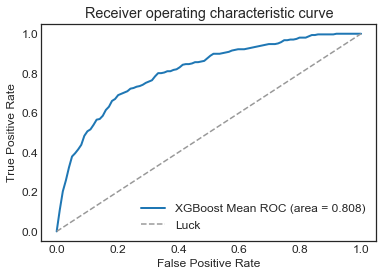

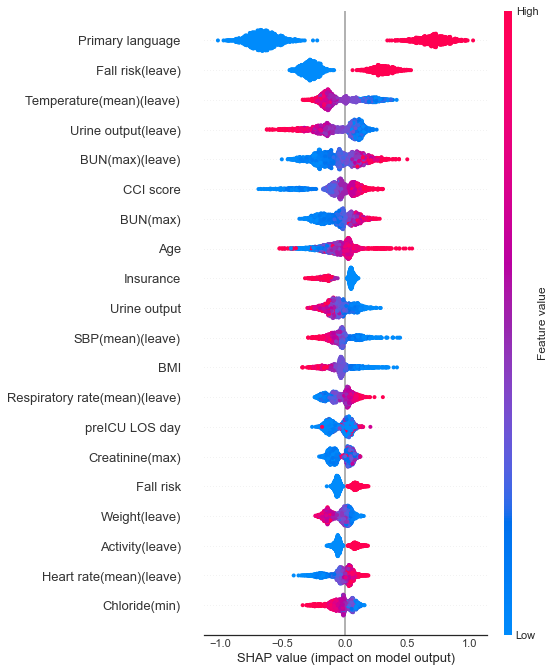

In [180]:
classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

# get_model_train_performance(classifier_xgb, X, y, 'XGBoost')
get_model_test_performance(classifier_xgb, X, y, X_test, y_test, 'XGBoost')
model_interpret(classifier_xgb, X_test)

## 只有Reweighing

In [181]:
train_pp_bld = BinaryLabelDataset(df=pd.concat((X, y),axis=1),
#                                   df=pd.concat((X_resampled, y_resampled),axis=1),
                                  label_names=['death_1year'],
                                  protected_attribute_names=['Primary language'],
#                                   protected_attribute_names=['language_english', 'language_unknown','language_other', 'Medicare'],
#                                   protected_attribute_names=['language'],
                                  favorable_label=1,
                                  unfavorable_label=0)

privileged_groups = [{'Primary language': 1 ,}]
unprivileged_groups = [{'Primary language': 0,}]

rw = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
train_pp_bld_f = rw.fit_transform(train_pp_bld)

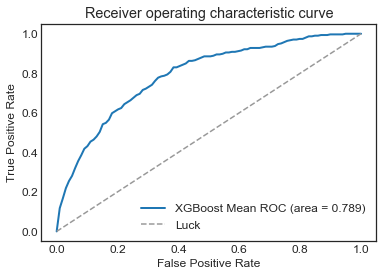

In [182]:
reweighing_classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

get_model_test_performance(reweighing_classifier_xgb, X, y, X_test, y_test, 'XGBoost', sample_weight=train_pp_bld_f)
# model_interpret(reweighing_classifier_xgb, X_test)

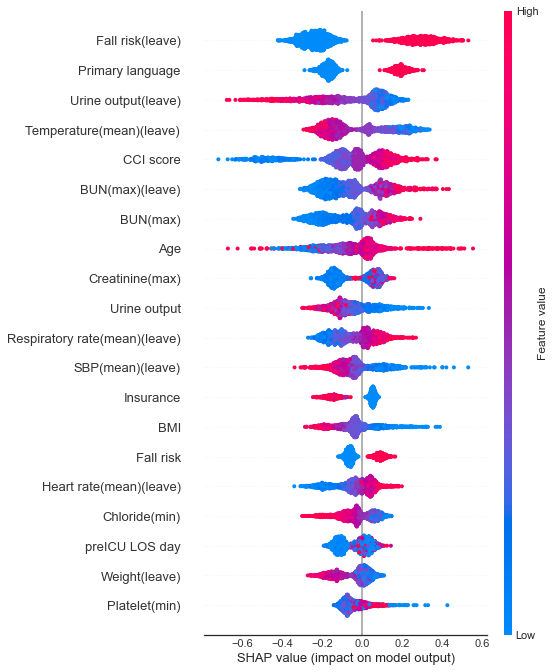

In [183]:
model_interpret(reweighing_classifier_xgb, X_test)

In [197]:
shap_values = shap.TreeExplainer(reweighing_classifier_xgb).shap_values(X_test)
# 可视化第一个prediction的解释 ,如果不想用JS,传入matplotlib=True
survivor_case_index = y_test[y_test.iloc[:,0]==0].index[7]  # survivor
# survivor shap case
shap.force_plot(shap.TreeExplainer(reweighing_classifier_xgb).expected_value, shap_values[survivor_case_index, :], X_test.iloc[survivor_case_index, :])

In [198]:
# non-survivor shap case
non_survivor_case_index = y_test[y_test.iloc[:,0]==1].index[0] # non-survivor
shap.force_plot(shap.TreeExplainer(reweighing_classifier_xgb).expected_value, shap_values[non_survivor_case_index, :], X_test.iloc[non_survivor_case_index, :])

# 模型对比

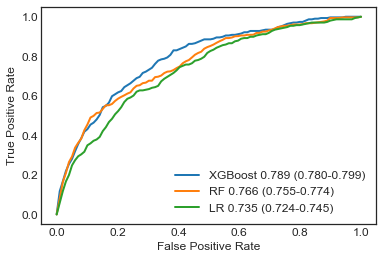

In [184]:
reweighing_classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

classifier_rf = RandomForestClassifier(n_estimators=1000,
                               random_state=1,
                               n_jobs=-1)

classifier_lr = LogisticRegression(C=1, penalty='l1', solver='liblinear')

get_model_test_comparison(reweighing_classifier_xgb, X, y, X_test, y_test, 'XGBoost', sample_weight=train_pp_bld_f)
get_model_test_comparison(classifier_rf, X, y, X_test, y_test, 'RF', sample_weight=train_pp_bld_f)
get_model_test_comparison(classifier_lr, X, y, X_test, y_test, 'LR', sample_weight=train_pp_bld_f)

#画对角线
# plt.plot([0, 1], [0, 1], '--', color=(0.6, 0.6, 0.6), label='Luck')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.savefig("./model_compare3.png", bbox_inches='tight', dpi=600)
plt.show()

# data first day vs last day

In [189]:
# 选取列
select_columns5 = ["preICU LOS day","Admission type",'Age','Gender', 'Ethnicity', 'Marital',
                  'Weight', 'SpO2/FiO2', #'Weight(leave)', 'Weight change',
                  'BMI', 
               "Insurance",
#                   'Medicaid', 'Medicare',
                  "Primary language", 
#                   "language_english", "language_unknown", "language_other",
                  "Elective surgery", "Ventilation", 
                  'Creatinine(max)','Bilirubin(max)',
                  'Platelet(min)','BUN(max)','WBC(max)', 'Glucose(max)',
                  'Hematocrit(max)','Potassium(max)','Sodium(max)','Bicarbonate(min)','Bicarbonate(max)',# 'pao2fio2ratio_novent',
                  'Albumin(min)','ALT(max)','AST(max)','ALP(max)', 'PT(max)',
                  'PTT(max)','INR(min)', 'Hemoglobin(min)','Chloride(min)','PaO2(min)','PaCO2(max)', 'Lactate(max)',
                  'BaseExcess(min)','FiO2(max)','Troponin(max)', 'Lymphocytes(max)','Lymphocytes(min)', 'Neutrophils(min)',
                  'Magnesium(max)',#'fibrinogen_min',#'bnp_max',
                  'Aniongap(max)','GCS(min)', #'gcseyes', 'gcsmotor','gcsverbal',
                  'Urine output','SpO2(min)','Heart rate(mean)', 'MBP(mean)',
                  'SBP(mean)','Respiratory rate(mean)','Temperature(mean)',
                  
                  'Vasopressor', 'Milrinone', 'Furosemide', # 升压药、强心剂、利尿剂
                  
#                   'bilirubin_max_eva_flag', 'pao2fio2ratio_vent_eva_flag', 'albumin_min_eva_flag', 'alt_max_eva_flag', 
#                   'ast_max_eva_flag', 'alp_max_eva_flag', 'pao2_min_eva_flag', 'paco2_max_eva_flag', 'lactate_max_eva_flag', 
#                   'baseexcess_min_eva_flag', 'fio2_max_eva_flag', 'troponin_max_eva_flag', 'lymphocytes_max_eva_flag',
#                   'lymphocytes_min_eva_flag', 'neutrophils_min_eva_flag', 
                  
                   'Activity', #'activity_eva_flag', 
                   'Fall risk', #'fall_risk_eva_flag',# 'history_fall', 'history_fall_eva_flag',
                   'Braden nutrition', #'braden_nutrition_eva_flag', 
                   'Braden mobility', #'braden_mobility_eva_flag',
                   'Braden activity', #'braden_activity_eva_flag', #'edema_location', 'edema_location_eva_flag',
                   'LLL Lung sounds', #'lll_lung_sounds_eva_flag', 
                   'LUL Lung sounds', #'lul_lung_sounds_eva_flag',
                   'RLL Lung sounds', #'rll_lung_sounds_eva_flag', 
                   'RUL Lung sounds', #'rul_lung_sounds_eva_flag',
                   'CCI score', #, 'anchor_year_group', 'db_source','death_30_90_day'
                    ]

select_columns6= ["preICU LOS day","Admission type",'Age','Gender', 'Ethnicity', 'Marital',
                  'Weight', 'SpO2/FiO2', 'Weight(leave)', 'Weight change',
                  'BMI', 
               "Insurance",
#                   'Medicaid', 'Medicare',
                  "Primary language", 
                  "Elective surgery", 
                   'CCI score', #, 'anchor_year_group', 'db_source','death_30_90_day'
               
                  'Ventilation(leave)', 'Creatinine(max)(leave)', #'bilirubin_max_leave',
                  'Platelet(min)(leave)','BUN(max)(leave)','WBC(max)(leave)','Glucose(max)(leave)',               
                  'Hematocrit(max)(leave)','Potassium(max)(leave)','Sodium(max)(leave)','Bicarbonate(min)(leave)','Bicarbonate(max)(leave)',
               # 'pao2fio2ratio_novent',
#                   'PaO2/FiO2(leave)','Albumin(min)(leave)','ALT(max)(leave)','AST(max)(leave)','ALP(max)(leave)',
                  'PT(max)(leave)','PTT(max)(leave)','INR(min)(leave)',
#                   'pt_max_leave_eva_flag', 'ptt_max_leave_eva_flag', 'inr_min_leave_eva_flag',
                  'Hemoglobin(min)(leave)','Chloride(min)(leave)',
#                   'PaO2(min)','PaCO2(max)', 'Lactate(max)',
#                   'BaseExcess(min)','FiO2(max)','Troponin(max)', 'Lymphocytes(max)','Lymphocytes(min)', 'Neutrophils(min)',
                  'Magnesium(max)(leave)',#'fibrinogen_min',#'bnp_max',
                  'Aniongap(max)(leave)','GCS(min)(leave)', #'gcseyes', 'gcsmotor','gcsverbal',
                  'Urine output(leave)','SpO2(min)(leave)','Heart rate(mean)(leave)', 'MBP(mean)(leave)',
                  'SBP(mean)(leave)','Respiratory rate(mean)(leave)','Temperature(mean)(leave)',
#                   'Vasopressor(leave)', 'Milrinone(leave)', 'Furosemide(leave)',
              
                   'Activity(leave)', #'activity_eva_flag_leave', 
                   'Fall risk(leave)', #'fall_risk_eva_flag_leave', 
                   'Braden nutrition(leave)', #'braden_nutrition_eva_flag_leave', 
                   'Braden mobility(leave)', #'braden_mobility_eva_flag_leave',
                   'Braden activity(leave)', #'braden_activity_eva_flag_leave', # 'edema_location_leave', 'edema_location_eva_flag_leave', 

                   'LLL Lung sounds(leave)', #'lll_lung_sounds_eva_flag_leave', 
                   'LUL Lung sounds(leave)', #'lul_lung_sounds_eva_flag_leave',
                   'RLL Lung sounds(leave)', #'rll_lung_sounds_eva_flag_leave', 
                   'RUL Lung sounds(leave)', #'rul_lung_sounds_eva_flag_leave'
                  
                    ]

X5 = X.loc[:, select_columns5]
X_test5 = X_test.loc[:, select_columns5]

X6 = X.loc[:, select_columns6]
X_test6 = X_test.loc[:, select_columns6]

In [186]:
def cal_auc(model, x_test, y_test):
    mean_tpr_xgb = 0.0
    mean_fpr_xgb = np.linspace(0, 1, 100)
    
    probas_ = model.predict_proba(x_test)
    fpr, tpr, thresholds = roc_curve(y_test, probas_[:, 1])
    mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr)			#对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
    mean_tpr_xgb[0] = 0.0

    # xgboost 平均AUC
    mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
    mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值
    
    sorts, l_limit_idx, u_limit_idx = cal_confidence_interval(model, x_test, y_test)
    
    print('AUC = %0.3f [%0.3f-%0.3f]' % (mean_auc_xgb, sorts[l_limit_idx], sorts[u_limit_idx]))


def model_learn_compare(x_train, y_train, x_test, y_test, sample_weight=False):
    # 机器学习模型
    reweighing_classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

#     classifier_rf = RandomForestClassifier(n_estimators=1000,
#                                    random_state=1,
#                                    n_jobs=-1)

#     classifier_lr = LogisticRegression(C=1, penalty='l1', solver='liblinear')
    
    models = [reweighing_classifier_xgb]
    # train
    if sample_weight:
        for model in models:
            model.fit(x_train, y_train, sample_weight=sample_weight.instance_weights)
    else:
        for model in models:
            model.fit(x_train, y_train)
            
    # test
    for model in models:
        cal_auc(model, x_test, y_test)

In [187]:
def get_reweight(x, y):
    train_pp_bld = BinaryLabelDataset(df=pd.concat((X, y),axis=1),
#                                   df=pd.concat((X_resampled, y_resampled),axis=1),
                                  label_names=['death_1year'],
                                  protected_attribute_names=['Primary language'],
#                                   protected_attribute_names=['language_english', 'language_unknown','language_other', 'Medicare'],
#                                   protected_attribute_names=['language'],
                                  favorable_label=1,
                                  unfavorable_label=0)

    privileged_groups = [{'Primary language': 1 ,}]
    unprivileged_groups = [{'Primary language': 0,}]

    rw = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
    train_pp_bld_f = rw.fit_transform(train_pp_bld)
    
    return train_pp_bld_f

In [188]:
model_learn_compare(X, y, X_test, y_test, sample_weight=train_pp_bld_f)

AUC = 0.789 [0.780-0.799]


In [190]:
model_learn_compare(X5, y, X_test5, y_test, sample_weight=get_reweight(X5, y))

AUC = 0.775 [0.767-0.784]


In [191]:
def model_learn_compare3(x_train, y_train, x_test, y_test, sample_weight=False):
    # 机器学习模型
    reweighing_classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

#     classifier_rf = RandomForestClassifier(n_estimators=1000,
#                                    random_state=1,
#                                    n_jobs=-1)

#     classifier_lr = LogisticRegression(C=1, penalty='l1', solver='liblinear')
    
    models = [reweighing_classifier_xgb]
    # train
    if sample_weight:
        for model in models:
            model.fit(x_train, y_train, sample_weight=sample_weight.instance_weights)
    else:
        for model in models:
            model.fit(x_train, y_train)
            
    # test
    for model in models:
        cal_auc(model, x_test, y_test)

In [192]:
model_learn_compare3(X6, y, X_test6, y_test, sample_weight=get_reweight(X6, y))

AUC = 0.786 [0.777-0.794]


# Model performance details

In [194]:
#  调整阈值的评价函数

from functools import reduce

def find_optimal_cutoff2(tpr,fpr,threshold):
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = threshold[optimal_idx]
    return optimal_threshold


def best_confusion_matrix2(y_test, y_test_predprob):
    fpr, tpr, thresholds = roc_curve(y_test, y_test_predprob, pos_label=1)
    cutoff = find_optimal_cutoff2(tpr,fpr,thresholds)
    y_pred = list(map(lambda x:1 if x>=cutoff else 0,y_test_predprob))
    TN,FP,FN,TP = confusion_matrix(y_test,y_pred).ravel()
    return cutoff,TN,FN,FP,TP


def evaluation2(clf, X_test, y_test, digits):

    y_test_predprob = clf.predict_proba(X_test)[:, 1]
    test_auc = round(roc_auc_score(y_test, y_test_predprob), digits)
    
    test_cutoff, TN2,FN2,FP2,TP2 = best_confusion_matrix2(y_test, y_test_predprob)

    #Sen Spe
    best_recall,best_prec = round(TP2/(TP2+FN2),digits), round(TN2/(FP2+TN2),digits)
    
    #F1值
    y_test_pred=list(map(lambda x:1 if x>=test_cutoff else 0,y_test_predprob))
    f1 = round(f1_score(y_test, y_test_pred),digits)
    
    #Accuracy值
    acc = round(accuracy_score(y_test, y_test_pred),digits)
    #Precision值
    prec = round(precision_score(y_test, y_test_pred),digits)
    #AUPRC值
    auprc = round(average_precision_score(y_test, y_test_pred),digits)
    
    
    evals = (test_auc, best_prec, best_recall, acc, f1, prec, auprc)
    return evals

# evaluation(classifier_xgb, X, y, X_test,y_test, "XGBoost",3)


def cal_exterval(lists, sample_lens):
    z_value = 1.960
    low = np.mean(lists) - z_value * np.std(lists)/np.sqrt(sample_lens)
    up = np.mean(lists) + z_value * np.std(lists)/np.sqrt(sample_lens)
    
    sorts = sorted(lists)
    
    x =95
    k = len(sorts)
    gap = (k - (x/100)*k)/2
    l_limit_idx = int(gap)
    u_limit_idx = int(k-gap)
    
    return r"%0.3f (%0.3f-%0.3f)"%(np.mean(np.array(lists)), sorts[l_limit_idx], sorts[u_limit_idx])


def cal_details(model, x_test, y_test):
    test_auc_list, best_prec_list, best_recall_list, acc_list, f1_list, prec_list, auprc_list = [], [], [], [], [], [], []
    test_lens = 0
    
    for i in range(100):
        # 随机采样训练集合
        x_external_val_test = x_test.sample(frac = 0.9, random_state = i)
        y_external_val_test = y_test.loc[x_external_val_test.index, :]

        test_lens = x_external_val_test.shape[0]

        evals = evaluation2(model, x_external_val_test, y_external_val_test, 3)
        (test_auc, best_prec, best_recall, acc, f1, prec, auprc) = evals
        test_auc_list.append(test_auc)
        best_prec_list.append(best_prec)
        best_recall_list.append(best_recall)
        acc_list.append(acc)
        f1_list.append(f1)
        prec_list.append(prec)
        auprc_list.append(auprc)
    
    a = cal_exterval(test_auc_list, test_lens)
    b = cal_exterval(best_prec_list, test_lens)
    c = cal_exterval(best_recall_list, test_lens)
    d = cal_exterval(acc_list, test_lens)
    e = cal_exterval(f1_list, test_lens)
    f = cal_exterval(prec_list, test_lens)
    g = cal_exterval(auprc_list, test_lens)
    
    exterval_eval_df = {'Index(95% CI)': ['AUC','Specificity','Sensitivity','Accuracy', 'F1 score', 'Precision', 'AUPRC'], 'External Validation': [a, b, c, d, e, f, g]}
    exterval_eval_df = pd.DataFrame(data=exterval_eval_df)
    print(exterval_eval_df)


def model_learn_performace_details(x_train, y_train, x_test, y_test, sample_weight=False):
    # 机器学习模型
    reweighing_classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

    classifier_rf = RandomForestClassifier(n_estimators=1000,
                                   random_state=1,
                                   n_jobs=-1)

    classifier_lr = LogisticRegression(C=1, penalty='l1', solver='liblinear')
    
    models = [reweighing_classifier_xgb, classifier_rf, classifier_lr]
    # train
    if sample_weight:
        for model in models:
            model.fit(x_train, y_train, sample_weight=sample_weight.instance_weights)
    else:
        for model in models:
            model.fit(x_train, y_train)
            
    # test
    for model in models:
        cal_details(model, x_test, y_test)

In [195]:
model_learn_performace_details(X, y, X_test, y_test, sample_weight=train_pp_bld_f)

  Index(95% CI)  External Validation
0           AUC  0.789 (0.780-0.799)
1   Specificity  0.634 (0.616-0.673)
2   Sensitivity  0.816 (0.770-0.844)
3      Accuracy  0.660 (0.644-0.688)
4      F1 score  0.401 (0.389-0.416)
5     Precision  0.266 (0.255-0.283)
6         AUPRC  0.243 (0.233-0.253)
  Index(95% CI)  External Validation
0           AUC  0.766 (0.756-0.774)
1   Specificity  0.809 (0.733-0.846)
2   Sensitivity  0.585 (0.535-0.667)
3      Accuracy  0.777 (0.721-0.805)
4      F1 score  0.425 (0.389-0.454)
5     Precision  0.338 (0.279-0.379)
6         AUPRC  0.254 (0.229-0.277)
  Index(95% CI)  External Validation
0           AUC  0.735 (0.724-0.745)
1   Specificity  0.749 (0.733-0.778)
2   Sensitivity  0.612 (0.577-0.640)
3      Accuracy  0.730 (0.717-0.752)
4      F1 score  0.388 (0.376-0.404)
5     Precision  0.284 (0.273-0.304)
6         AUPRC  0.228 (0.218-0.239)


# 亚组分析

In [53]:
columns_base = ["preICU LOS day","Admission type",'Age','Gender', 'Ethnicity', 'Marital',
                  'Weight', 'Weight(leave)', 'Weight change', 'SpO2/FiO2',
                  'BMI', "Insurance",
#                   'Medicaid', 'Medicare',
                  "Primary language", 
#                   "language_english", "language_unknown", "language_other",
                  "Elective surgery", "Ventilation", 
                  'Creatinine(max)','Bilirubin(max)',
                  'Platelet(min)','BUN(max)','WBC(max)', 'Glucose(max)',
                  'Hematocrit(max)','Potassium(max)','Sodium(max)','Bicarbonate(min)','Bicarbonate(max)',# 'pao2fio2ratio_novent',
#                   'PaO2/FiO2',
                  'Albumin(min)','ALT(max)','AST(max)','ALP(max)', 'PT(max)',
                  'PTT(max)','INR(min)', 'Hemoglobin(min)','Chloride(min)','PaO2(min)','PaCO2(max)', 'Lactate(max)',
                  'BaseExcess(min)','FiO2(max)','Troponin(max)', 'Lymphocytes(max)','Lymphocytes(min)', 'Neutrophils(min)',
                  'Magnesium(max)',#'fibrinogen_min',#'bnp_max',
                  'Aniongap(max)','GCS(min)', #'gcseyes', 'gcsmotor','gcsverbal',
                  'Urine output','SpO2(min)','Heart rate(mean)', 'MBP(mean)',
                  'SBP(mean)','Respiratory rate(mean)','Temperature(mean)',
                  
                  'Vasopressor', 'Milrinone', 'Furosemide', # 升压药、强心剂、利尿剂
                  
                  'bilirubin_max_eva_flag', 'albumin_min_eva_flag', 'alt_max_eva_flag', 
                  'ast_max_eva_flag', 'alp_max_eva_flag', 'pao2_min_eva_flag', 'paco2_max_eva_flag', 'lactate_max_eva_flag', 
                  'baseexcess_min_eva_flag', 'fio2_max_eva_flag', 'troponin_max_eva_flag', 'lymphocytes_max_eva_flag',
                  'lymphocytes_min_eva_flag', 'neutrophils_min_eva_flag', 
                  
                   'Activity', #'activity_eva_flag', 
                   'Fall risk', #'fall_risk_eva_flag',# 'history_fall', 'history_fall_eva_flag',
                   'Braden nutrition', #'braden_nutrition_eva_flag', 
                   'Braden mobility', #'braden_mobility_eva_flag',
                   'Braden activity', #'braden_activity_eva_flag', #'edema_location', 'edema_location_eva_flag',
                   'LLL Lung sounds', #'lll_lung_sounds_eva_flag', 
                   'LUL Lung sounds', #'lul_lung_sounds_eva_flag',
                   'RLL Lung sounds', #'rll_lung_sounds_eva_flag', 
                   'RUL Lung sounds', #'rul_lung_sounds_eva_flag',
                   'CCI score', #, 'anchor_year_group', 'db_source','death_30_90_day'
                  
#                   'death_1year',
               
                  'Ventilation(leave)', 'Creatinine(max)(leave)', #'bilirubin_max_leave',
                  'Platelet(min)(leave)','BUN(max)(leave)','WBC(max)(leave)','Glucose(max)(leave)',               
                  'Hematocrit(max)(leave)','Potassium(max)(leave)','Sodium(max)(leave)','Bicarbonate(min)(leave)','Bicarbonate(max)(leave)',
               # 'pao2fio2ratio_novent',
#                   'PaO2/FiO2(leave)','Albumin(min)(leave)','ALT(max)(leave)','AST(max)(leave)','ALP(max)(leave)',
                  'PT(max)(leave)','PTT(max)(leave)','INR(min)(leave)',
               
                  'pt_max_leave_eva_flag', 'ptt_max_leave_eva_flag', 'inr_min_leave_eva_flag',
               
                  'Hemoglobin(min)(leave)','Chloride(min)(leave)',
#                   'PaO2(min)','PaCO2(max)', 'Lactate(max)',
#                   'BaseExcess(min)','FiO2(max)','Troponin(max)', 'Lymphocytes(max)','Lymphocytes(min)', 'Neutrophils(min)',
                  'Magnesium(max)(leave)',#'fibrinogen_min',#'bnp_max',
                  'Aniongap(max)(leave)','GCS(min)(leave)', #'gcseyes', 'gcsmotor','gcsverbal',
               
                  'Urine output(leave)','SpO2(min)(leave)','Heart rate(mean)(leave)', 'MBP(mean)(leave)',
                  'SBP(mean)(leave)','Respiratory rate(mean)(leave)','Temperature(mean)(leave)',
#                    'Vasopressor(leave)', 'Milrinone(leave)', 'Furosemide(leave)',
               
               'vasopressor_leave', 'milrinone_leave', 'furosemide_leave',
              
                   'Activity(leave)', #'activity_eva_flag_leave', 
                   'Fall risk(leave)', #'fall_risk_eva_flag_leave', 
                   'Braden nutrition(leave)', #'braden_nutrition_eva_flag_leave', 
                   'Braden mobility(leave)', #'braden_mobility_eva_flag_leave',
                   'Braden activity(leave)', #'braden_activity_eva_flag_leave', # 'edema_location_leave', 'edema_location_eva_flag_leave', 

                   'LLL Lung sounds(leave)', #'lll_lung_sounds_eva_flag_leave', 
                   'LUL Lung sounds(leave)', #'lul_lung_sounds_eva_flag_leave',
                   'RLL Lung sounds(leave)', #'rll_lung_sounds_eva_flag_leave', 
                   'RUL Lung sounds(leave)', #'rul_lung_sounds_eva_flag_leave'
               ]

columns_insurance = columns_base.copy()
columns_insurance.remove('Insurance')
columns_language = columns_base.copy()
columns_language.remove('Primary language')

columns_acivity = columns_base.copy()
columns_acivity.remove('Activity')
columns_acivity.remove('Activity(leave)')
columns_fall = columns_base.copy()
columns_fall.remove('Fall risk')
columns_fall.remove('Fall risk(leave)')
columns_nutrition = columns_base.copy()
columns_nutrition.remove('Braden nutrition')
columns_nutrition.remove('Braden nutrition(leave)')
columns_braden_mobility = columns_base.copy()
columns_braden_mobility.remove('Braden mobility')
columns_braden_mobility.remove('Braden mobility(leave)')
columns_braden_activity = columns_base.copy()
columns_braden_activity.remove('Braden activity')
columns_braden_activity.remove('Braden activity(leave)')

columns_lll_lungsound= columns_base.copy()
columns_lll_lungsound.remove('LLL Lung sounds')
columns_lll_lungsound.remove('LLL Lung sounds(leave)')
columns_lul_lungsound = columns_base.copy()
columns_lul_lungsound.remove('LUL Lung sounds')
columns_lul_lungsound.remove('LUL Lung sounds(leave)')
columns_rll_lungsound = columns_base.copy()
columns_rll_lungsound.remove('RLL Lung sounds')
columns_rll_lungsound.remove('RLL Lung sounds(leave)')
columns_rul_lungsound = columns_base.copy()
columns_rul_lungsound.remove('RUL Lung sounds')
columns_rul_lungsound.remove('RUL Lung sounds(leave)')


X_base = X
X_base_test = X_test

X_insurance = X.loc[:, columns_insurance]
X_insurance_test = X_test.loc[:, columns_insurance]

X_language = X.loc[:, columns_language]
X_language_test = X_test.loc[:, columns_language]

X_activity = X.loc[:, columns_acivity]
X_activity_test = X_test.loc[:, columns_acivity]

X_fall = X.loc[:, columns_fall]
X_fall_test = X_test.loc[:, columns_fall]

X_nutrition = X.loc[:, columns_nutrition]
X_nutrition_test = X_test.loc[:, columns_nutrition]

X_braden_mobility = X.loc[:, columns_braden_mobility]
X_braden_mobility_test = X_test.loc[:, columns_braden_mobility]

X_braden_activity = X.loc[:, columns_braden_activity]
X_braden_activity_test = X_test.loc[:, columns_braden_activity]


X_lll_lungsound = X.loc[:, columns_lll_lungsound]
X_lll_lungsound_test = X_test.loc[:, columns_lll_lungsound]

X_lul_lungsound = X.loc[:, columns_lul_lungsound]
X_lul_lungsound_test = X_test.loc[:, columns_lul_lungsound]

X_rll_lungsound = X.loc[:, columns_rll_lungsound]
X_rll_lungsound_test = X_test.loc[:, columns_rll_lungsound]

X_rul_lungsound = X.loc[:, columns_rul_lungsound]
X_rul_lungsound_test = X_test.loc[:, columns_rul_lungsound]

In [91]:
def get_reweight(x, y):
    train_pp_bld = BinaryLabelDataset(df=pd.concat((X, y),axis=1),
#                                   df=pd.concat((X_resampled, y_resampled),axis=1),
                                  label_names=['death_1year'],
                                  protected_attribute_names=['Primary language'],
#                                   protected_attribute_names=['language_english', 'language_unknown','language_other', 'Medicare'],
#                                   protected_attribute_names=['language'],
                                  favorable_label=1,
                                  unfavorable_label=0)

    privileged_groups = [{'Primary language': 1 ,}]
    unprivileged_groups = [{'Primary language': 0,}]

    rw = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
    train_pp_bld_f = rw.fit_transform(train_pp_bld)
    
    return train_pp_bld_f

In [172]:
def cal_test_auc_list2(model, x_test, y_test):
    auc_list = []
    for i in range(100):
        # 随机采样训练集合
        x_external_val_test = x_test.sample(frac = 0.9, random_state = i)
        y_external_val_test = y_test.loc[x_external_val_test.index, :]

        mean_tpr_xgb = 0.0
        mean_fpr_xgb = np.linspace(0, 1, 100)

        probas_ = model.predict_proba(x_external_val_test)
        fpr, tpr, thresholds = roc_curve(y_external_val_test, probas_[:, 1])
        mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr)			#对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
        mean_tpr_xgb[0] = 0.0

        # xgboost 平均AUC
        mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
        mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值

        auc_list.append(mean_auc_xgb)
        
    return auc_list

def model_learn_compare2(x_train, y_train, x_test, y_test, sample_weight=False):
    # 机器学习模型
    reweighing_classifier_xgb = XGBClassifier(min_child_weight=0.01,
                               subsample=0.6,
                               colsample_bytree=0.6,
                               objective= 'binary:logistic', #逻辑回归损失函数
                               scale_pos_weight=4,
                               reg_alpha=0,
                               reg_lambda=0,
                               seed=27,
                               gamma=0.1,
                               learning_rate=0.01,
                               max_depth=7,
                               n_estimators=800)

    
    model = reweighing_classifier_xgb
    # train
    if sample_weight:
        model.fit(x_train, y_train, sample_weight=sample_weight.instance_weights)
    else:
        model.fit(x_train, y_train)
            
    # test
    test_auc_list = cal_test_auc_list2(model, x_test, y_test)
    return test_auc_list

In [173]:
base_auc = model_learn_compare2(X_base, y, X_base_test, y_test, sample_weight=get_reweight(X_base, y))

insurance_auc = model_learn_compare2(X_insurance, y, X_insurance_test, y_test, sample_weight=get_reweight(X_insurance, y))
language_auc = model_learn_compare2(X_language, y, X_language_test, y_test, sample_weight=False)#get_reweight(X_language, y))

In [174]:
fall_auc = model_learn_compare2(X_fall, y, X_fall_test, y_test, sample_weight=get_reweight(X_fall, y))
activity_auc = model_learn_compare2(X_activity, y, X_activity_test, y_test, sample_weight=get_reweight(X_activity, y))
braden_nutrition_auc = model_learn_compare2(X_nutrition, y, X_nutrition_test, y_test, sample_weight=get_reweight(X_nutrition, y))
braden_mobility_auc = model_learn_compare2(X_braden_mobility, y, X_braden_mobility_test, y_test, sample_weight=get_reweight(X_braden_mobility, y))
braden_activity_auc = model_learn_compare2(X_braden_activity, y, X_braden_activity_test, y_test, sample_weight=get_reweight(X_braden_activity, y))

In [175]:
lll_lungsound_auc = model_learn_compare2(X_lll_lungsound, y, X_lll_lungsound_test, y_test, sample_weight=get_reweight(X_lll_lungsound, y))
lul_lungsound_auc = model_learn_compare2(X_lul_lungsound, y, X_lul_lungsound_test, y_test, sample_weight=get_reweight(X_lul_lungsound, y))
rll_lungsound_auc = model_learn_compare2(X_rll_lungsound, y, X_rll_lungsound_test, y_test, sample_weight=get_reweight(X_rll_lungsound, y))
rul_lungsound_auc = model_learn_compare2(X_rul_lungsound, y, X_rul_lungsound_test, y_test, sample_weight=get_reweight(X_rul_lungsound, y))

In [176]:
# base_auc = model_learn_compare2(X_base, y, X_base_test, y_test, sample_weight=train_pp_bld_f)

# insurance_auc = model_learn_compare2(X_insurance, y, X_insurance_test, y_test, sample_weight=train_pp_bld_f)
# language_auc = model_learn_compare2(X_language, y, X_language_test, y_test, sample_weight=train_pp_bld_f)
# # ethnicity_auc = model_learn_compare2(X_ethnicity, y, X_ethnicity_test, y_test, sample_weight=False)
# # marital_auc = model_learn_compare2(X_marital, y, X_marital_test, y_test, sample_weight=False)

# fall_auc = model_learn_compare2(X_fall, y, X_fall_test, y_test, sample_weight=train_pp_bld_f)
# activity_auc = model_learn_compare2(X_activity, y, X_activity_test, y_test, sample_weight=train_pp_bld_f)
# braden_nutrition_auc = model_learn_compare2(X_nutrition, y, X_nutrition_test, y_test, sample_weight=train_pp_bld_f)
# braden_mobility_auc = model_learn_compare2(X_braden_mobility, y, X_braden_mobility_test, y_test, sample_weight=train_pp_bld_f)
# braden_activity_auc = model_learn_compare2(X_braden_activity, y, X_braden_activity_test, y_test, sample_weight=train_pp_bld_f)

# lll_lungsound_auc = model_learn_compare2(X_lll_lungsound, y, X_lll_lungsound_test, y_test, sample_weight=train_pp_bld_f)
# lul_lungsound_auc = model_learn_compare2(X_lul_lungsound, y, X_lul_lungsound_test, y_test, sample_weight=train_pp_bld_f)
# rll_lungsound_auc = model_learn_compare2(X_rll_lungsound, y, X_rll_lungsound_test, y_test, sample_weight=train_pp_bld_f)
# rul_lungsound_auc = model_learn_compare2(X_rul_lungsound, y, X_rul_lungsound_test, y_test, sample_weight=train_pp_bld_f)


sub_df = pd.DataFrame({'ALL': base_auc, 
                       'Insurance': insurance_auc, 'Language': language_auc, 
#                        'Ethnicity': ethnicity_auc, 'Marital':marital_auc,
                       'Fall risk':fall_auc, 'Activity':activity_auc, 
                       'Braden nutrition':braden_nutrition_auc,'Braden mobility':braden_mobility_auc,
                       'Braden activity':braden_activity_auc,
                       'lll_lungsound': lll_lungsound_auc,
                       'lul_lungsound': lul_lungsound_auc,
                       'rll_lungsound': rll_lungsound_auc,
                       'rul_lungsound': rul_lungsound_auc,
                      })
sub_df

,ALL,Insurance,Language,Fall risk,Activity,Braden nutrition,Braden mobility,Braden activity,lll_lungsound,lul_lungsound,rll_lungsound,rul_lungsound
0,0.791004,0.785808,0.782392,0.782211,0.787188,0.787661,0.787334,0.787443,0.789514,0.786534,0.789041,0.790967
1,0.784707,0.779674,0.775385,0.775315,0.779249,0.779603,0.780028,0.778682,0.780631,0.777335,0.779957,0.781588
2,0.791689,0.789392,0.783631,0.780020,0.788408,0.787605,0.786584,0.786183,0.788736,0.785527,0.788480,0.788663
3,0.786358,0.783880,0.776783,0.778172,0.783204,0.781927,0.781777,0.780988,0.784556,0.779561,0.782791,0.784480
4,0.793895,0.789327,0.785428,0.786765,0.789550,0.790478,0.790255,0.788881,0.790515,0.787842,0.789847,0.792669
...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.788100,0.783308,0.779842,0.780211,0.785151,0.785925,0.785704,0.784377,0.787768,0.784672,0.786478,0.787326
96,0.786029,0.782722,0.777102,0.776640,0.782544,0.783042,0.782864,0.780232,0.783433,0.781583,0.782366,0.783824
97,0.791555,0.788399,0.783163,0.783757,0.789253,0.788510,0.789736,0.786579,0.790107,0.786913,0.789996,0.790590
98,0.786501,0.779890,0.777319,0.774968,0.780661,0.781837,0.780073,0.779522,0.781396,0.778935,0.781359,0.783453


[0.7888080763644544, 0.7843809278235202, 0.7793558148575574, 0.7795777326135708, 0.7847982645915694, 0.7850055137383457, 0.7847264584447718, 0.7832460668006455, 0.7862169929752261, 0.7827752116313603, 0.7854436355385586, 0.786610134113414]


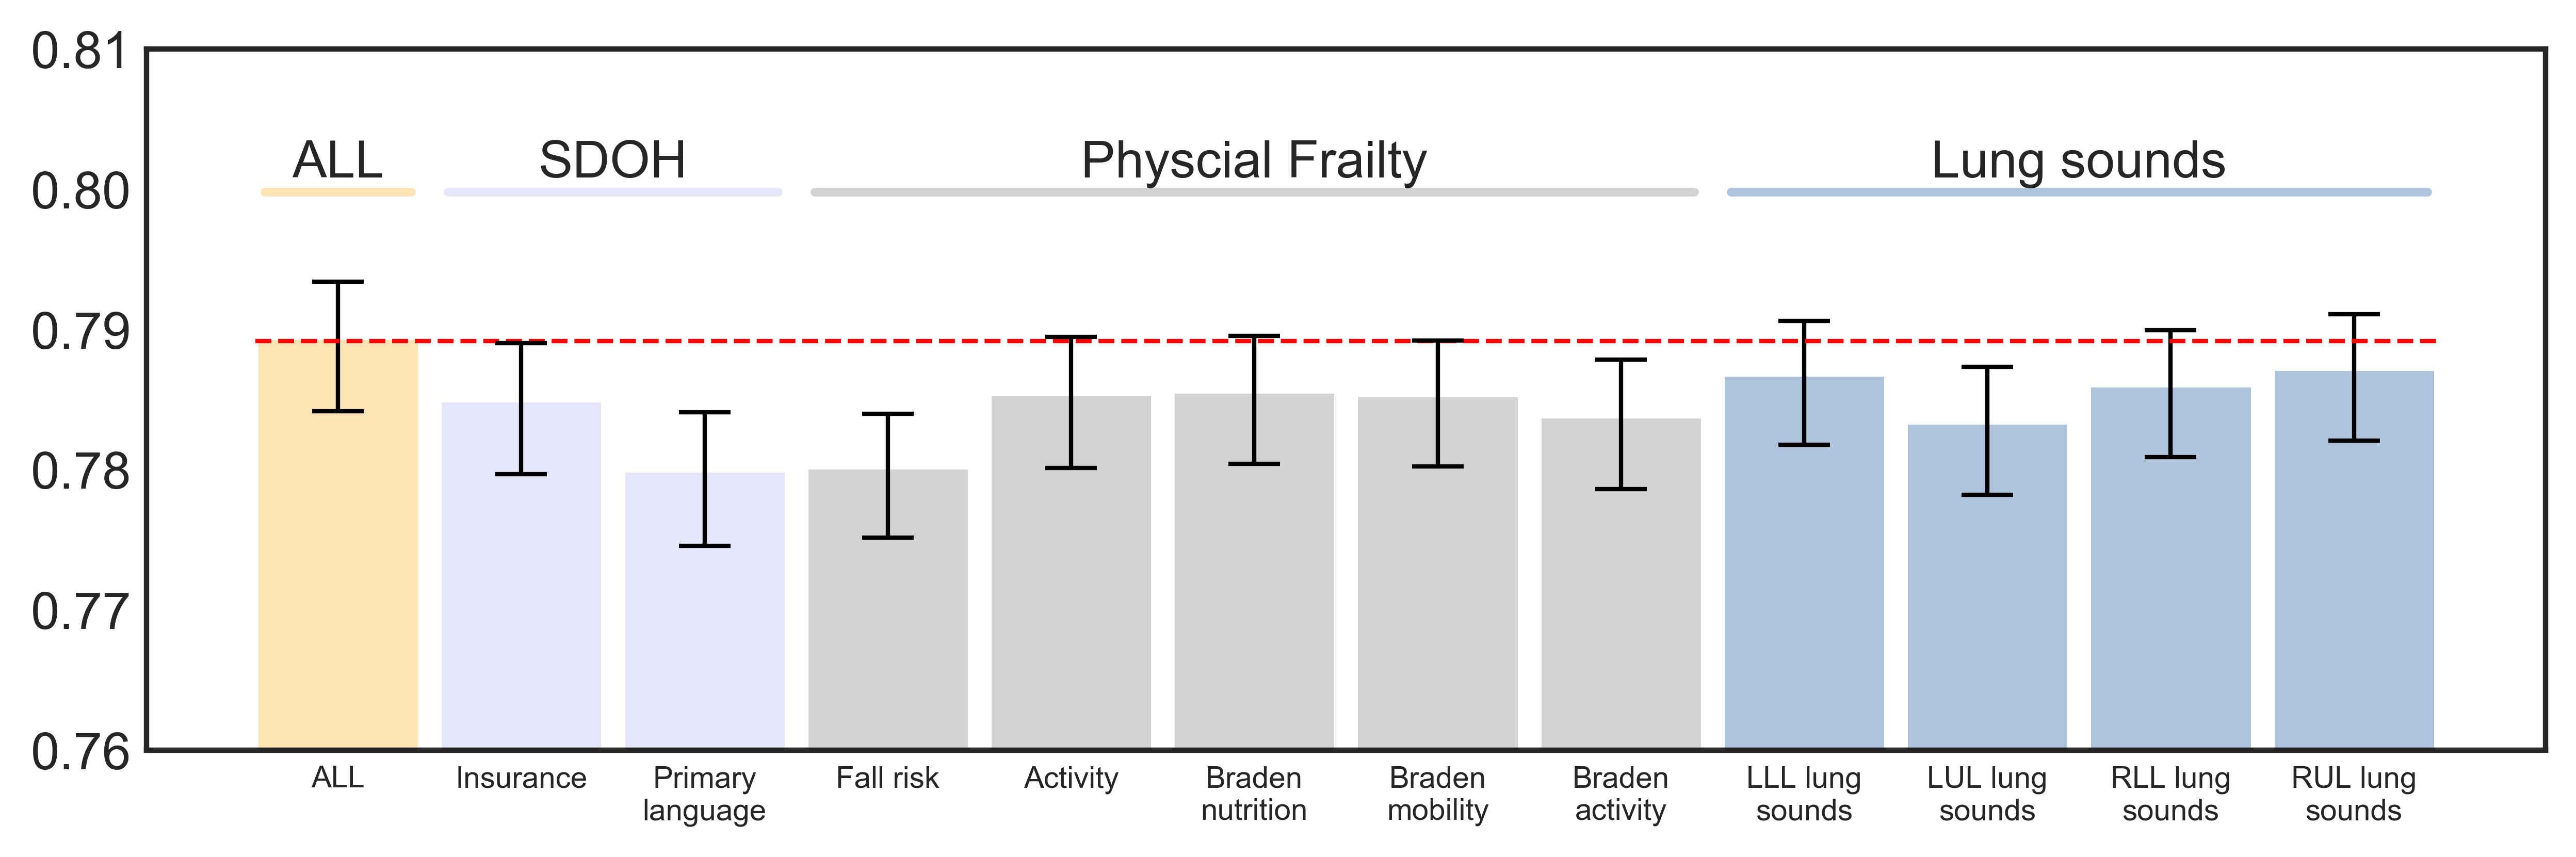

In [196]:
x_title = ['ALL', 'Insurance', 'Primary\nlanguage'] + ['Fall risk', 'Activity', 'Braden\nnutrition', 'Braden\nmobility', 'Braden\nactivity'] + ['LLL lung\nsounds', 'LUL lung\nsounds', 'RLL lung\nsounds', 'RUL lung\nsounds']
color = ['#FFE4B5', '#E6E6FA', '#E6E6FA'] + ['#D3D3D3','#D3D3D3','#D3D3D3','#D3D3D3','#D3D3D3']+['#B0C4DE', '#B0C4DE', '#B0C4DE', '#B0C4DE']

plt.figure(figsize=(10,3),dpi=600)
ax=plt.gca()

#柱状图数据前处理
x = np.linspace(1, len(x_title), len(x_title)) #分类先设置为整数，便于后期优化
mean = []
std = []
 
for i in sub_df.columns.to_list():
    mean.append(sub_df.loc[:, i].mean())#平均值
    std.append(sub_df.loc[:, i].std())#标准差
print(mean)

ax.set_ylim([0.76, 0.81])
ax.bar(x, mean, color=color, edgecolor=color, linewidth=3)

ax.plot([x[0]-0.45,x[11]+0.45], [mean[0]+0.0004, mean[0]+0.0004], color='red', linewidth=1, linestyle='--')

#一个一个添加误差棒
for i in range(len(x_title)):
    ax.errorbar(x[i], mean[i], yerr=std[i], ecolor='black', elinewidth=1, capsize=6, capthick=1)

#横坐标转化    
majorLocator = plt.FixedLocator(x)
from matplotlib.ticker import AutoMinorLocator
minorLocator = AutoMinorLocator(len(x_title)-1)
 
ax.xaxis.set_major_locator(majorLocator)
ax.set_xticklabels(x_title, fontsize=7)


##标注p值
#标注p值，plt_p函数是统计两组数据之间的p值
def plt_p_all(a, b, c):
    x1 = [x[a]-0.4, x[b]+0.4]
    x2 = (x[a]+x[b])/2.0
    y1 = [c*1.0 - 0.005, c*1.0- 0.005]
    y2 = c*1.0 - 0.003
    ax.plot(x1, y1, color=color[0], linewidth=2)
    ax.text(x2, y2, "ALL", verticalalignment='center', horizontalalignment='center')

def plt_p_age(a, b, c):
    x1 = [x[a]-0.2, x[b]+0.2]
#     x2 = (x[a]+x[b])/2.0
    x3 = [x[a]-0.4, x[b]+0.4]
    x4 = (x[a]+x[b])/2.0
    y1 = [c, c]
#     y2 = c+0.0002
    y3 = [c*1.0 - 0.005, c*1.0 - 0.005]
    y4 = c*1.0 - 0.003
    ax.plot(x3, y3, color=color[a], linewidth=2)
#     ax.plot(x1, y1, color="black", linewidth=1)
#     ax.text(x2, y2, "p<0.001", verticalalignment='center', horizontalalignment='center')
    ax.text(x4, y4, s[a], verticalalignment='center', horizontalalignment='center')

# #然后画含p的柱状图
s = ['Base', 'SDOH','SDOH', 'Physcial Frailty', 'Physcial Frailty','Physcial Frailty','Physcial Frailty','Physcial Frailty', 'Lung sounds', 'Lung sounds', 'Lung sounds', 'Lung sounds']
m = 1
c = (sub_df.loc[:, sub_df.columns.to_list()[m]].mean() + sub_df.loc[:, sub_df.columns.to_list()[m]].std())
plt_p_all(0, 0, c*1.02)
plt_p_age(1, 2, c*1.02)
plt_p_age(3, 7, c*1.02)
plt_p_age(8, 11, c*1.02)

plt.savefig("./subgroup3.png", bbox_inches='tight', dpi=600)
# plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")
plt.show()


# 不同特征数量

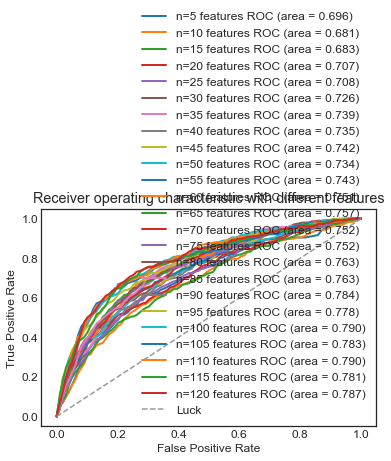

In [212]:
from sklearn.feature_selection import SelectFromModel
# Fit model using each importance as a threshold
auc_trains = []
auc_test = []
thresholds_model = np.sort(reweighing_classifier_xgb.feature_importances_)[::-1]
# print(thresholds_model)
for i in np.arange(5, 122, 5):
    # select features using threshold
    selection = SelectFromModel(reweighing_classifier_xgb, threshold=thresholds_model[i-1] , prefit=True)
    select_X_train = selection.transform(X)

    select_X_test = selection.transform(X_test)

    # train model
    selection_model = XGBClassifier()    
    mean_tpr_xgb = 0.0
    mean_fpr_xgb = np.linspace(0, 1, 100)
    
    #通过训练数据模型，并对测试集进行测试，求出预测得分
    selection_model.fit(select_X_train, y)  
    probas_ = selection_model.predict_proba(select_X_test)
    #通过roc_curve()函数，求出fpr和tpr，以及阈值
    fpr, tpr, thresholds = roc_curve(y_test, probas_[:, 1])
    mean_tpr_xgb += interp(mean_fpr_xgb, fpr, tpr) #对mean_tpr在mean_fpr处进行插值，通过scipy包调用interp()函数
    mean_tpr_xgb[0] = 0.0 #初始处为0
    roc_auc = auc(fpr, tpr)
        
    # xgboost 平均AUC
#     mean_tpr_xgb /= n_split #在mean_fpr100个点，每个点处插值插值多次取平均
    mean_tpr_xgb[-1] = 1.0 #坐标最后一个点为（1,1）
    mean_auc_xgb = auc(mean_fpr_xgb, mean_tpr_xgb)#计算平均AUC值
    
    auc_trains.append(mean_auc_xgb)

    #画平均ROC曲线
    plt.plot(mean_fpr_xgb, mean_tpr_xgb, label='n=%d features ROC (area = %0.3f)' % (select_X_train.shape[1], mean_auc_xgb), lw=2)

#画对角线
plt.plot([0, 1], [0, 1], '--', color=(0.6, 0.6, 0.6), label='Luck')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic with different features')
plt.legend(loc="lower right")
plt.show()